In [1]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


GPU available: False
Device name: CPU only


In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import nbformat
import IPython
import plotly

In [3]:
print("Python:", sys.executable)
print("nbformat:", nbformat.__version__)
print("IPython:", IPython.__version__)
print("Plotly:", plotly.__version__)

Python: c:\Users\jagad\Documents\my_classes\Tasks\projects_of_guvi\Final_project_Deep_learning\.venvdeep\Scripts\python.exe
nbformat: 5.11.1
IPython: 9.16.1
Plotly: 7.0.0


### Step - 1 - Load the Dataset

In [4]:
deepfake_df = pd.read_csv(r"C:\Users\jagad\Documents\my_classes\Tasks\projects_of_guvi\Final_project_Deep_learning\data\dataset.csv")

print("First five rows:")
print(deepfake_df.head())


First five rows:
   image_id                                          image_url label  gender  \
0         1  https://images.unsplash.com/photo-172422561835...  REAL  Female   
1         2  https://images.unsplash.com/photo-172422561873...  REAL    Male   
2         3  https://images.unsplash.com/photo-172422561834...  REAL  Female   
3         4  https://images.unsplash.com/photo-172422561855...  REAL  Female   
4         5  https://images.unsplash.com/photo-172422561823...  REAL    Male   

  age_group  
0     18-25  
1       50+  
2     36-50  
3     26-35  
4     36-50  


#### Explore the data

In [5]:
# To find the shape of the data:
print("Datashape: ", deepfake_df.shape)
print("-" * 50)

# To find data type of each fearures:
print("\nInformation: ")
print(deepfake_df.info())
print("-" * 50)

# To find null values in each count:
print("\nSum of misisng values: ")
print(deepfake_df.isnull().sum())
print("-" * 50)

# To find duplicate values:
print("\nDuplicate values: ", deepfake_df.duplicated().sum())
print("-" * 50)

Datashape:  (6557, 5)
--------------------------------------------------

Information: 
<class 'pandas.DataFrame'>
RangeIndex: 6557 entries, 0 to 6556
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   image_id   6557 non-null   int64
 1   image_url  6557 non-null   str  
 2   label      6557 non-null   str  
 3   gender     6557 non-null   str  
 4   age_group  6557 non-null   str  
dtypes: int64(1), str(4)
memory usage: 256.3 KB
None
--------------------------------------------------

Sum of misisng values: 
image_id     0
image_url    0
label        0
gender       0
age_group    0
dtype: int64
--------------------------------------------------

Duplicate values:  0
--------------------------------------------------


#### To find counts in Label feature

In [6]:
print(deepfake_df['label'].value_counts())

label
FAKE    3767
REAL    2790
Name: count, dtype: int64


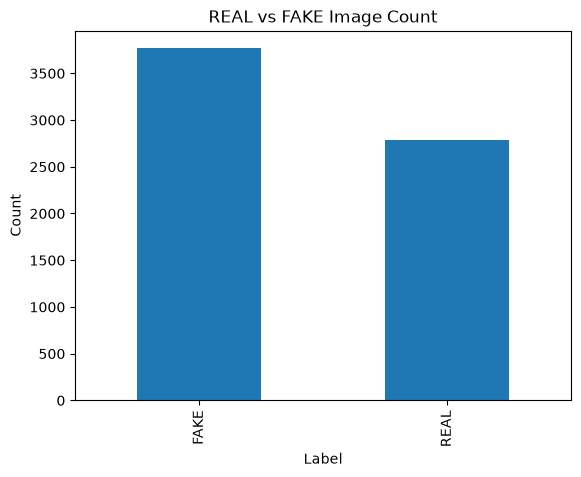

In [7]:
deepfake_df['label'].value_counts().plot(kind='bar')
plt.title('REAL vs FAKE Image Count')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [8]:
label_counts = deepfake_df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']

fig = px.bar(
                label_counts,
                x='Label',
                y='Count',
                title='REAL vs FAKE Image Count',
                color='Label'
                )

fig.update_layout(  height = 500, width = 500,
                    xaxis_title='Label',
                    yaxis_title='Count'
                )

fig.show()

#### To Find the count of Gender

In [9]:
print(deepfake_df['gender'].value_counts())

gender
Unknown    4507
Female     1033
Male       1017
Name: count, dtype: int64


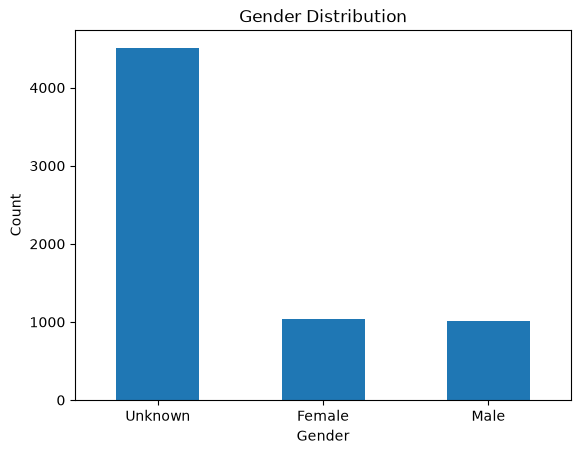

In [10]:
gender_counts = deepfake_df['gender'].value_counts()

gender_counts.plot(
    kind='bar'
)

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [11]:
gender_counts = deepfake_df['gender'].value_counts().reset_index()
gender_counts.columns = ['Gender', 'Count']

fig = px.bar(
            gender_counts,
            x='Gender',
            y='Count',
            title='Gender Distribution',
            color='Gender'
            )

fig.update_layout(  height = 500, width = 500,
                    xaxis_title='Gender',
                    yaxis_title='Count'
                 )

fig.show()

#### To find the count of Age_group

In [12]:
print(deepfake_df['age_group'].value_counts())

age_group
18-25    1681
36-50    1670
26-35    1650
50+      1556
Name: count, dtype: int64


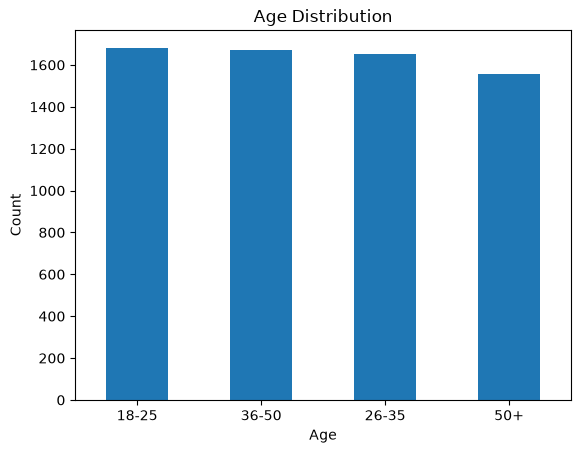

In [13]:
age_group_counts = deepfake_df['age_group'].value_counts()

age_group_counts.plot(
                        kind='bar'
                    )

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [14]:
age_group_counts = deepfake_df['age_group'].value_counts().reset_index()
age_group_counts.columns = ['Age', 'Count']

fig = px.bar(
            age_group_counts,
            x='Age',
            y='Count',
            title='Age Distribution',
            color='Age'
            )

fig.update_layout(  height = 500, width = 500,
                    xaxis_title='Age',
                    yaxis_title='Count'
                 )

fig.show()